In [1]:
import pandas as pd

df = pd.read_csv('/content/Housing.csv')
display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [3]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


### Convert Binary Categorical Columns to Numerical
Many columns like `mainroad`, `guestroom`, etc., have 'yes'/'no' values. These will be converted to 1s and 0s respectively.

In [4]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

display(df[binary_cols].head())

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


### One-Hot Encode `furnishingstatus`
The `furnishingstatus` column has more than two categories, so it's best to use one-hot encoding.

In [5]:
print('Unique values in furnishingstatus:', df['furnishingstatus'].unique())

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
display(df.head())

Unique values in furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


Now, let's check the `info()` again to confirm all categorical columns have been converted.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

### Identify Target Variable
In this dataset, 'price' is the target variable that we aim to predict.

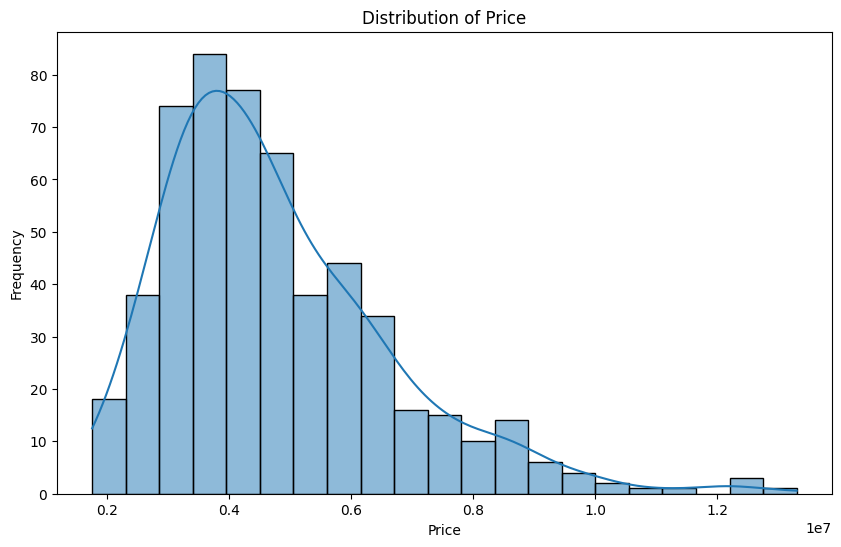

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [8]:
print('Descriptive statistics for Price:')
display(df['price'].describe())

Descriptive statistics for Price:


,price
count,5.450000e+02
mean,4.766729e+06
std,1.870440e+06
min,1.750000e+06
25%,3.430000e+06
50%,4.340000e+06
75%,5.740000e+06
max,1.330000e+07


### Data Preparation for Modeling
First, we need to separate the features (X) from the target variable (y). Then, we will split the data into training and testing sets to evaluate the model's performance on unseen data.

In [9]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (436, 13)
X_test shape: (109, 13)
y_train shape: (436,)
y_test shape: (109,)


### Model Training
Now, we will initialize a Linear Regression model and train it using our training data.

In [10]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Predict Housing Prices
Using the trained linear regression model, we will now make predictions on the unseen test data (`X_test`).

In [11]:
y_pred = model.predict(X_test)

print("First 5 predictions:")
display(y_pred[:5])

print("First 5 actual values:")
display(y_test[:5])

First 5 predictions:


array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.32722559, 3294646.25725955])

First 5 actual values:


,price
316,4060000
77,6650000
360,3710000
90,6440000
493,2800000


### Evaluate Model Performance: Mean Squared Error
To quantitatively assess how well our model's predictions align with the actual housing prices, we will calculate the Mean Squared Error (MSE). MSE measures the average squared difference between the estimated values and the actual value, providing an indicator of the model's prediction accuracy.

In [12]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 1754318687330.6633


### Calculate Root Mean Squared Error (RMSE)
To make the error metric more interpretable, we will calculate the Root Mean Squared Error (RMSE), which is the square root of the MSE. RMSE is in the same units as the target variable (price), making it easier to understand the typical magnitude of prediction errors.

In [13]:
import numpy as np

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 1324506.9600914384


### Visualize Predicted vs. Actual Values
A scatter plot of predicted vs. actual values can provide a good visual understanding of the model's performance. Ideally, points should fall along the 45-degree line, indicating perfect predictions.

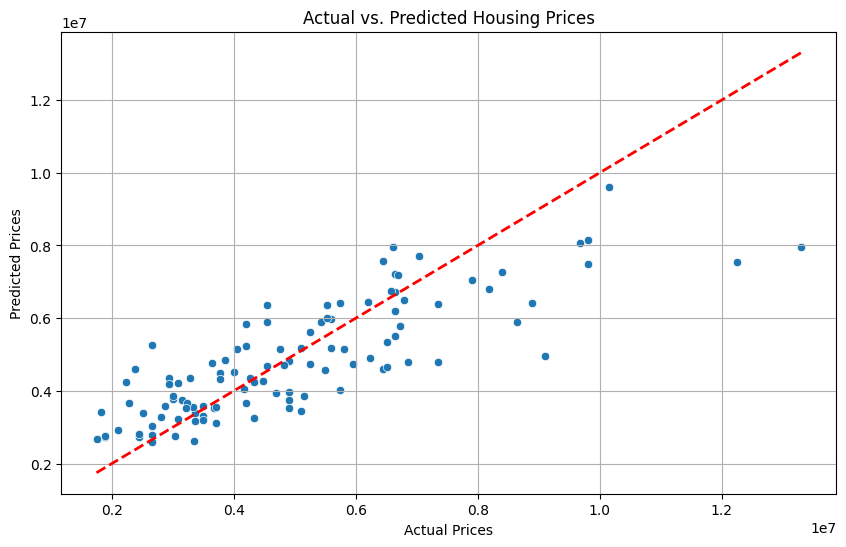

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Housing Prices')
plt.grid(True)
plt.show()

### Identify Potential Outliers in Housing Price Data
We can use a box plot to visualize the distribution of 'price' and identify any data points that lie beyond the whiskers, which are considered potential outliers.

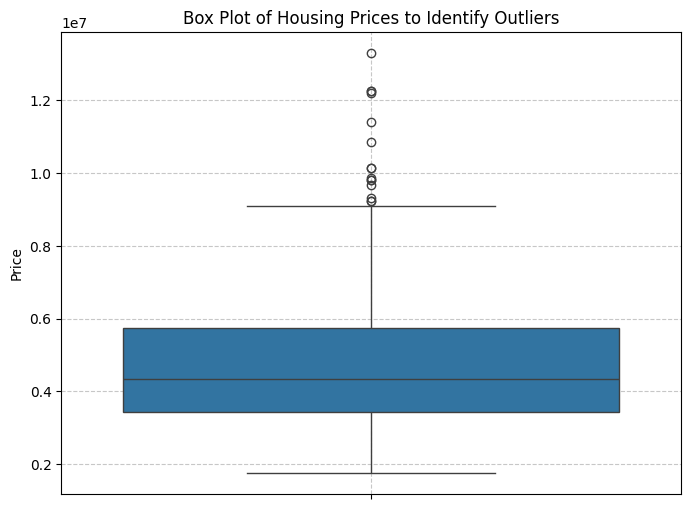

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['price'])
plt.title('Box Plot of Housing Prices to Identify Outliers')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()